## Nama: M Muzammil Aditya Putra
## Nim: 4222301055
## Kelas: 6B-Pagi


# Image Classification menggunakan Transfer Learning
# Deteksi Jenis Sampah di Sekitar Kampus

**Dataset:** Trash Type Image Dataset — [Kaggle](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)  
**Kelas:** Cardboard, Glass, Metal, Paper, Plastic, Trash  
**Framework:** TensorFlow / Keras  
**Model:** MobileNetV2 (pre-trained ImageNet) sebagai feature extractor

---


## 1. Download Dataset dari Kaggle

In [13]:
import os
DATA_DIR = 'Archive/TrashType_Image_Dataset'
print('Kelas yang tersedia:', os.listdir(DATA_DIR))


Kelas yang tersedia: ['cardboard', 'metal', 'trash', 'plastic', 'glass', 'paper']


## 2. Import Library

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.21.0


## 3. Preprocessing dan Data Augmentation

Data generator menggunakan `preprocess_input` khusus MobileNetV2 (bukan rescale 1/255), agar normalisasi citra sesuai dengan yang digunakan saat model MobileNetV2 di-pretrain pada ImageNet.

In [15]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2      # 80% train, 20% validasi
)

train_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names = list(train_data.class_indices.keys())

print(f'Kelas yang terdeteksi : {train_data.class_indices}')
print(f'Jumlah data training  : {train_data.samples}')
print(f'Jumlah data validasi  : {val_data.samples}')


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Kelas yang terdeteksi : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Jumlah data training  : 2024
Jumlah data validasi  : 503


### 3.1 Visualisasi Sample Dataset

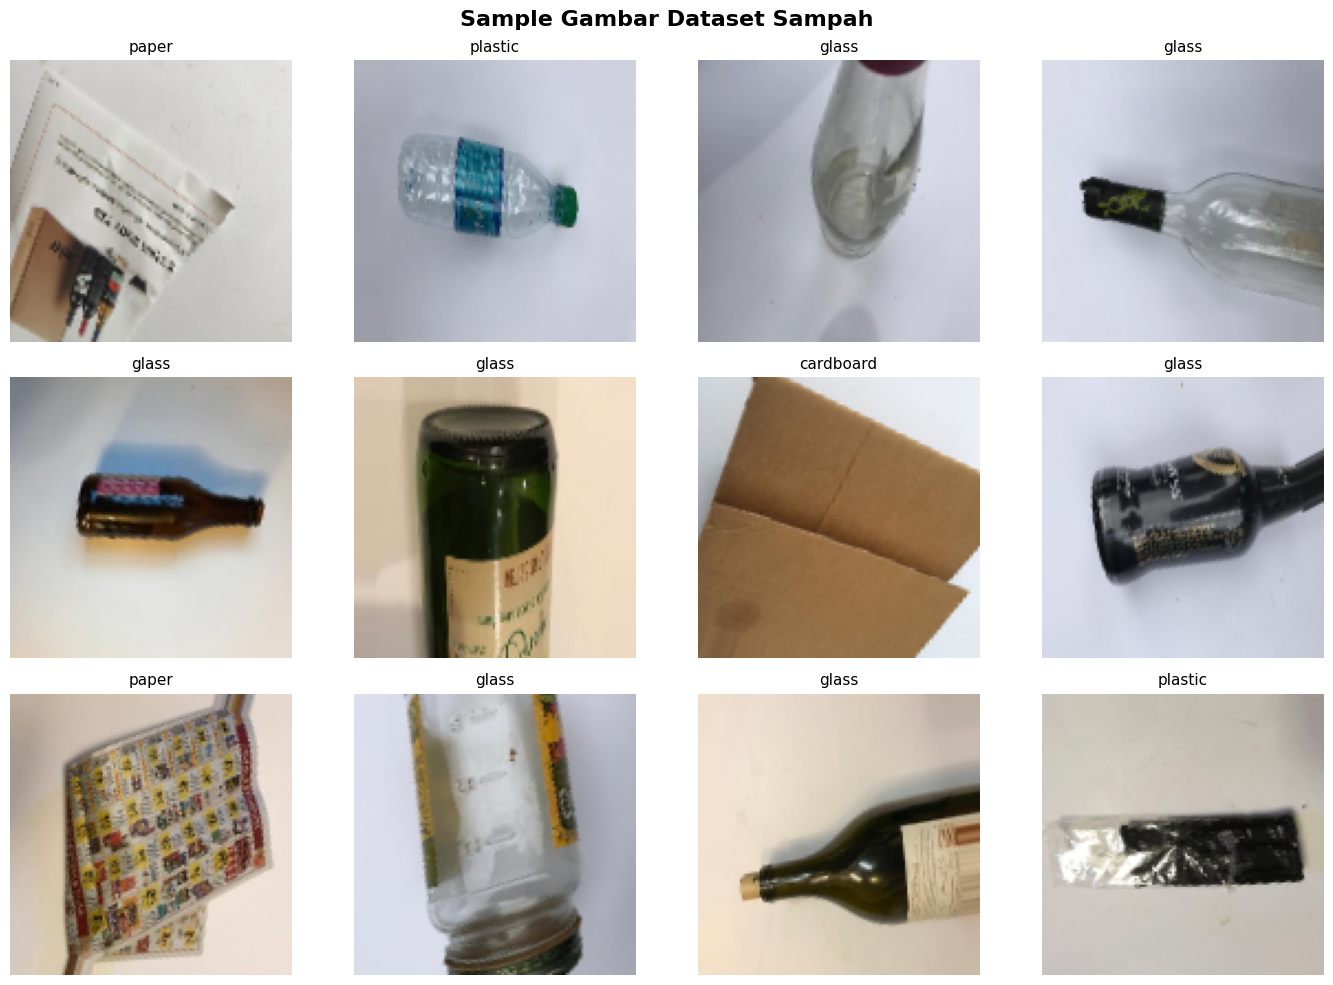

In [16]:
x_batch, y_batch = next(train_data)

# preprocess_input menghasilkan nilai piksel di rentang [-1, 1], dikembalikan ke [0, 1] untuk ditampilkan
x_display = (x_batch + 1) / 2.0

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Gambar Dataset Sampah', fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(np.clip(x_display[i], 0, 1))
    ax.set_title(class_names[np.argmax(y_batch[i])], fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 4. Membangun Model Transfer Learning (MobileNetV2)

MobileNetV2 dimuat dengan bobot pre-trained ImageNet tanpa top layer (`include_top=False`), lalu seluruh layer dasarnya dibekukan (`trainable = False`) sehingga fitur yang sudah dipelajari dari ImageNet tidak rusak selama training. Hanya layer klasifikasi baru di atasnya yang dilatih. `Dropout` dan regularisasi L2 ditambahkan pada layer Dense untuk mencegah overfitting.

In [17]:
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False   # bekukan seluruh layer MobileNetV2

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,358 (8.93 MB)

 Trainable params: 82,374 (321.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4.1 Compile dan Training

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr]
)

model.save('trash_classifier.h5')
print('\nModel tersimpan: trash_classifier.h5')


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.4363 - loss: 2.6989 - val_accuracy: 0.6759 - val_loss: 1.9947 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 629ms/step - accuracy: 0.5860 - loss: 2.0262 - val_accuracy: 0.7316 - val_loss: 1.6639 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 602ms/step - accuracy: 0.6487 - loss: 1.7421 - val_accuracy: 0.7396 - val_loss: 1.4769 - learning_rate: 0.0010
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 658ms/step - accuracy: 0.6828 - loss: 1.5262 - val_accuracy: 0.7714 - val_loss: 1.3283 - learning_rate: 0.0010
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 687ms/step - accuracy: 0.7021 - loss: 1.3836 - val_accuracy: 0.7992 - val_loss: 1.2074 - learning_rate: 0.0010
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 677ms/step - accuracy: 0.7317 - loss: 1.2798 - val_accuracy: 0.7654 - val_loss: 1.1830 - learning_rate: 0.0010
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 680ms/step - accuracy: 0.7564 - loss: 1.19


Model tersimpan: trash_classifier.h5


### 4.2 Visualisasi Kurva Training

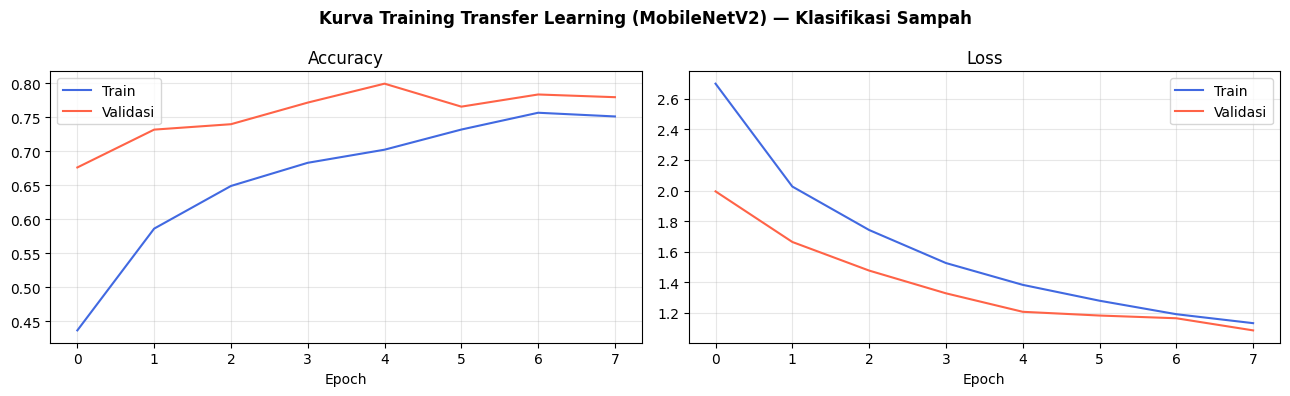

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Kurva Training Transfer Learning (MobileNetV2) — Klasifikasi Sampah', fontweight='bold')

ax1.plot(history.history['accuracy'],     label='Train',    color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Validasi', color='tomato')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train',    color='royalblue')
ax2.plot(history.history['val_loss'], label='Validasi', color='tomato')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.3 Evaluasi Model

In [20]:
val_loss, val_acc = model.evaluate(val_data, verbose=0)
print(f'Validation Accuracy : {val_acc*100:.2f}%')
print(f'Validation Loss     : {val_loss:.4f}')


Validation Accuracy : 78.93%
Validation Loss     : 1.2168


In [21]:
val_data.reset()
y_pred = np.argmax(model.predict(val_data, verbose=0), axis=1)
y_true = val_data.classes

print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=class_names))


=== Classification Report ===
              precision    recall  f1-score   support

   cardboard       0.96      0.82      0.89        80
       glass       0.82      0.80      0.81       100
       metal       0.79      0.85      0.82        82
       paper       0.71      0.89      0.79       118
     plastic       0.70      0.65      0.67        96
       trash       0.67      0.30      0.41        27

    accuracy                           0.78       503
   macro avg       0.77      0.72      0.73       503
weighted avg       0.78      0.78      0.77       503



### Confusion Matrix

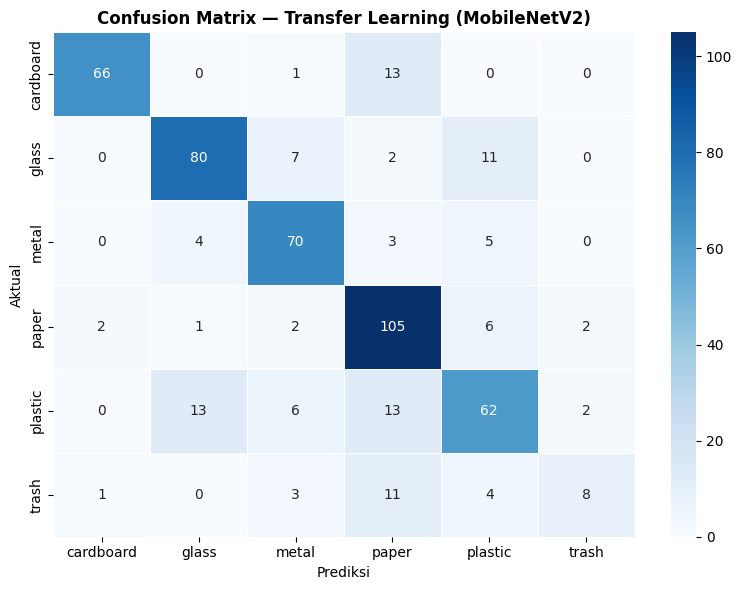

In [22]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Transfer Learning (MobileNetV2)', fontweight='bold')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout()
plt.show()


## 5. Analisis Overfitting

Overfitting terjadi apabila akurasi/loss pada data training jauh lebih baik dibandingkan pada data validasi, dan gap antara keduanya melebar seiring bertambahnya epoch. Sel di bawah menghitung gap tersebut secara otomatis dari history training di atas.

In [23]:
train_acc_final = history.history['accuracy'][-1]
val_acc_final   = history.history['val_accuracy'][-1]
train_loss_final = history.history['loss'][-1]
val_loss_final   = history.history['val_loss'][-1]

acc_gap  = train_acc_final - val_acc_final
loss_gap = val_loss_final - train_loss_final

print(f'Train Accuracy akhir : {train_acc_final*100:.2f}%')
print(f'Val Accuracy akhir   : {val_acc_final*100:.2f}%')
print(f'Gap Accuracy         : {acc_gap*100:.2f}%')
print(f'Train Loss akhir     : {train_loss_final:.4f}')
print(f'Val Loss akhir       : {val_loss_final:.4f}')
print(f'Gap Loss              : {loss_gap:.4f}')

if acc_gap > 0.10 or loss_gap > 0.15:
    print('\nKesimpulan: Masih terindikasi OVERFITTING meskipun sudah menggunakan transfer learning.')
    print('Saran penanganan lanjutan: turunkan learning rate awal, tambah Dropout, perbesar l2, atau '
          'kurangi jumlah epoch / perkecil kapasitas layer Dense.')
else:
    print('\nKesimpulan: Tidak terindikasi overfitting yang signifikan. Kombinasi transfer learning, '
          'Dropout, regularisasi L2, EarlyStopping, dan ReduceLROnPlateau berhasil menjaga gap train-val '
          'tetap kecil.')


Train Accuracy akhir : 75.10%
Val Accuracy akhir   : 77.93%
Gap Accuracy         : -2.83%
Train Loss akhir     : 1.1331
Val Loss akhir       : 1.0859
Gap Loss              : -0.0472

Kesimpulan: Tidak terindikasi overfitting yang signifikan. Kombinasi transfer learning, Dropout, regularisasi L2, EarlyStopping, dan ReduceLROnPlateau berhasil menjaga gap train-val tetap kecil.


## 6. Prediksi Gambar Baru

In [27]:
from tensorflow.keras.preprocessing import image

def predict_image(image_path):
    img = image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(image.load_img(image_path, target_size=(128, 128)))
    plt.title(f'Prediksi: {predicted_class.upper()}\nConfidence: {confidence:.1f}%',
              fontweight='bold')
    plt.axis('off')
    plt.show()

    print('\nSkor per kelas:')
    for cls, prob in zip(class_names, predictions):
        bar = '#' * int(prob * 30)
        print(f'  {cls:<12}: {bar:<30} {prob*100:5.1f}%')

# Contoh penggunaan:
# predict_image('foto_sampah.jpg')
